# Health Stream Telemedicine Analytics

Introduction

Health Stream Telemedicine Analytics is a healthcare IoT data engineering project designed to process patient monitoring data collected from wearable sensors. The system performs data ingestion, cleaning, transformation, storage, analysis, and visualization to support healthcare monitoring and decision-making.

Dataset Overview
Dataset Statistics
| Feature   | Value                  |
| --------- | ---------------------- |
| Records   | 200                    |
| Features  | 13                     |
| Data Type | Healthcare IoT         |
| Source    | Sensor Monitoring Data |


Important Attributes
- Patient_ID
- Timestamp
- Sensor_Type
- Temperature (°C)
- Systolic_BP
- Diastolic_BP
- Heart_Rate
- Battery_Level
- Target_Health_Status

Data Engineering Pipeline, 
    Healthcare IoT Dataset
            ↓
      Data Ingestion
            ↓
       Data Cleaning
            ↓
     Data Transformation
            ↓
      Feature Creation
            ↓
      SQLite Database
            ↓
      Data Analytics
            ↓
      Machine Learning
            ↓
     Streamlit Dashboard
            ↓
       Power BI Report

Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Load Dataset

In [14]:
df = pd.read_csv(
    "cleaned_healthcare_iot_dataset.csv"
)

df.head()

,Patient_ID,Timestamp,Sensor_ID,Sensor_Type,Temperature (°C),Systolic_BP,Diastolic_BP,Heart_Rate,Battery_Level,Target_Blood_Pressure,Target_Heart_Rate,Target_Health_Status,Battery_Level (%)
0,8270,2024-01-01 00:00:00,4,Temperature,36.8,150.0,95.0,84.0,99,140.0,90.0,Unhealthy,80
1,1860,2024-01-01 01:00:00,1,Battery,37.3,150.0,95.0,77.0,84,140.0,90.0,Unhealthy,94
2,6390,2024-01-01 02:00:00,1,Temperature,36.5,140.0,85.0,99.0,93,130.0,80.0,Healthy,84
3,6191,2024-01-01 03:00:00,4,Battery,37.3,120.0,80.0,67.0,95,150.0,90.0,Unhealthy,92
4,6734,2024-01-01 04:00:00,4,Temperature,36.8,90.0,60.0,98.0,97,120.0,80.0,Unhealthy,87


Dataset Information

In [15]:
print(df.shape)

df.info()

df.describe()

(200, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             200 non-null    int64  
 1   Timestamp              200 non-null    object 
 2   Sensor_ID              200 non-null    int64  
 3   Sensor_Type            200 non-null    object 
 4   Temperature (°C)       200 non-null    float64
 5   Systolic_BP            200 non-null    float64
 6   Diastolic_BP           200 non-null    float64
 7   Heart_Rate             200 non-null    float64
 8   Battery_Level          200 non-null    int64  
 9   Target_Blood_Pressure  200 non-null    float64
 10  Target_Heart_Rate      200 non-null    float64
 11  Target_Health_Status   200 non-null    object 
 12  Battery_Level (%)      200 non-null    int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 20.4+ KB


,Patient_ID,Sensor_ID,Temperature (°C),Systolic_BP,Diastolic_BP,Heart_Rate,Battery_Level,Target_Blood_Pressure,Target_Heart_Rate,Battery_Level (%)
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,5720.335000,2.575000,37.040500,125.800000,82.450000,80.400000,89.465000,132.050000,79.600000,89.865000
std,2588.799649,1.166697,0.291883,19.705367,11.637209,11.338554,5.678026,11.789506,7.624346,5.989671
min,1064.000000,1.000000,36.500000,90.000000,60.000000,60.000000,80.000000,120.000000,70.000000,80.000000
25%,3546.250000,1.750000,36.800000,120.000000,80.000000,70.000000,84.750000,120.000000,70.000000,85.000000
50%,6125.000000,3.000000,37.040000,130.000000,85.000000,82.000000,89.500000,130.000000,80.000000,90.000000
75%,7970.500000,4.000000,37.300000,140.000000,90.000000,89.000000,94.250000,140.000000,90.000000,95.000000
max,9996.000000,4.000000,37.500000,150.000000,95.000000,99.000000,99.000000,150.000000,90.000000,100.000000


Missing Values

In [16]:
df.isnull().sum()

Patient_ID               0
Timestamp                0
Sensor_ID                0
Sensor_Type              0
Temperature (°C)         0
Systolic_BP              0
Diastolic_BP             0
Heart_Rate               0
Battery_Level            0
Target_Blood_Pressure    0
Target_Heart_Rate        0
Target_Health_Status     0
Battery_Level (%)        0
dtype: int64

Duplicate Check

In [17]:
df.duplicated().sum()

np.int64(0)

Timestamp Conversion

In [18]:
df['Timestamp'] = pd.to_datetime(
    df['Timestamp']
)

Exploratory Data Analysis


Temperature Distribution

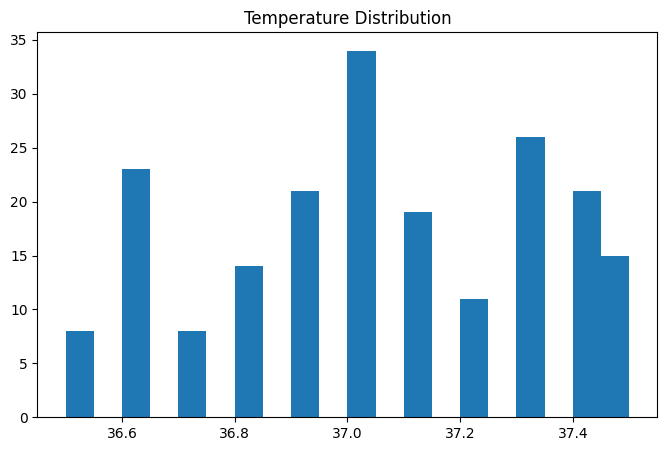

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Temperature (°C)'],
    bins=20
)

plt.title("Temperature Distribution")
plt.show()

Heart Rate Distribution

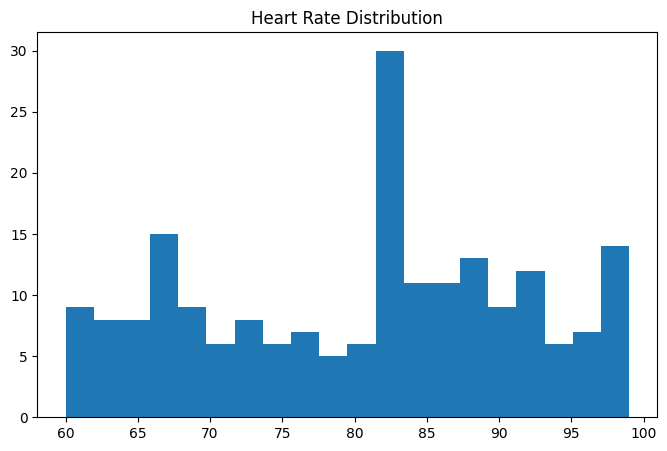

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Heart_Rate'],
    bins=20
)

plt.title("Heart Rate Distribution")
plt.show()

Battery Level Analysis

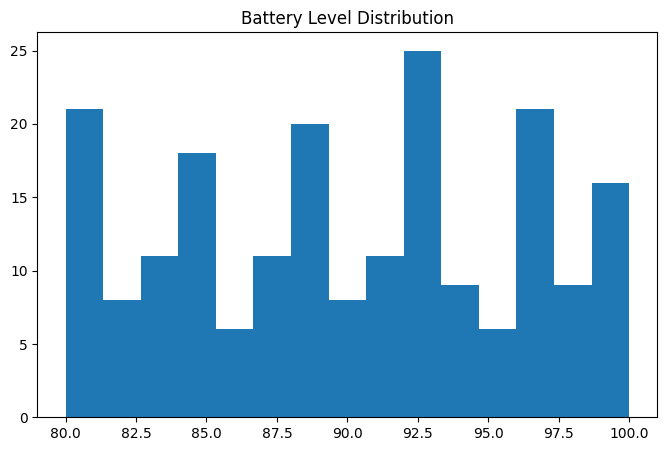

In [21]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Battery_Level (%)'],
    bins=15
)

plt.title("Battery Level Distribution")
plt.show()

Health Status Count

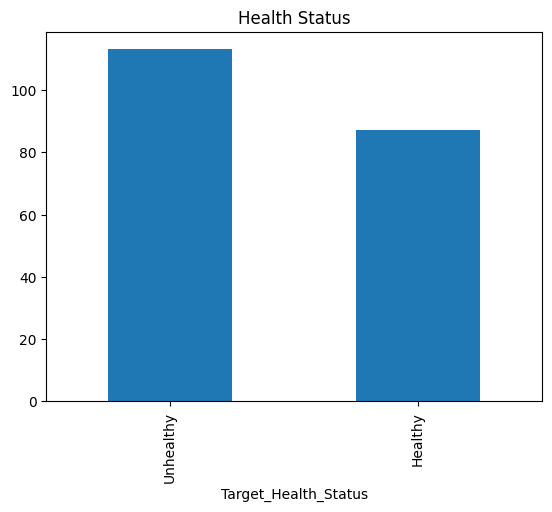

In [22]:
df['Target_Health_Status']\
.value_counts()\
.plot(kind='bar')

plt.title("Health Status")
plt.show()

Correlation Analysis

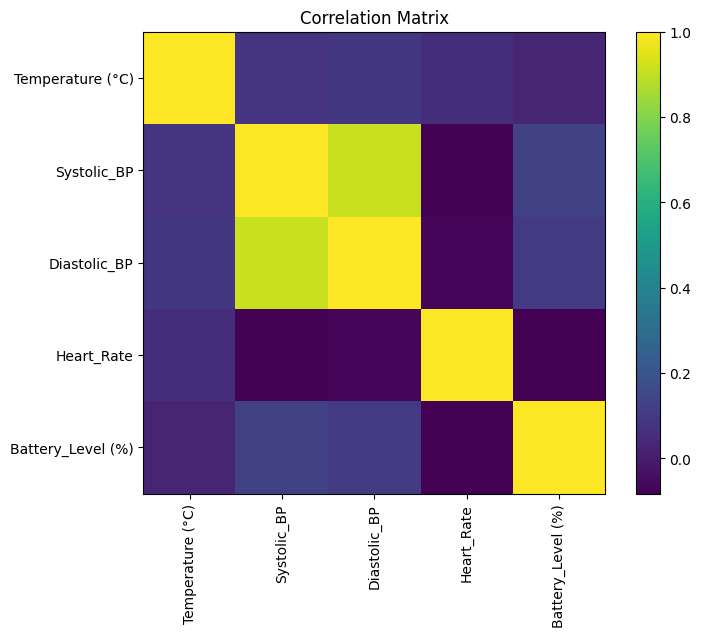

In [23]:
numeric_cols = [
    'Temperature (°C)',
    'Systolic_BP',
    'Diastolic_BP',
    'Heart_Rate',
    'Battery_Level (%)'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

Feature Engineering

Blood Pressure Category

In [24]:
def bp_category(x):

    if x > 140:
        return "High"

    elif x >= 120:
        return "Normal"

    else:
        return "Low"

df['BP_Category'] = \
df['Systolic_BP'].apply(
    bp_category
)

Heart Rate Category

In [25]:
def hr_category(x):

    if x > 100:
        return "High"

    elif x >= 60:
        return "Normal"

    else:
        return "Low"

df['HR_Category'] = \
df['Heart_Rate'].apply(
    hr_category
)

Database Storage

In [26]:
conn = sqlite3.connect(
    "healthstream.db"
)

df.to_sql(
    "health_data",
    conn,
    if_exists='replace',
    index=False
)

conn.close()

Machine Learning Model 1

Random Forest Classification

Predict Health Status

In [27]:
features = [
    'Temperature (°C)',
    'Systolic_BP',
    'Diastolic_BP',
    'Heart_Rate'
]

X = df[features]

encoder = LabelEncoder()

y = encoder.fit_transform(
    df['Target_Health_Status']
)

Train Test Split

In [28]:
X_train, X_test, y_train, y_test = \
train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [29]:
model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluation

In [30]:
pred = model.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

0.675
              precision    recall  f1-score   support

           0       0.65      0.61      0.63        18
           1       0.70      0.73      0.71        22

    accuracy                           0.68        40
   macro avg       0.67      0.67      0.67        40
weighted avg       0.67      0.68      0.67        40



Machine Learning Model 2

K-Means Clustering

Patient Risk Grouping

In [31]:
cluster_features = [
    'Temperature (°C)',
    'Heart_Rate',
    'Systolic_BP'
]

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(
    df[cluster_features]
)

Visualization

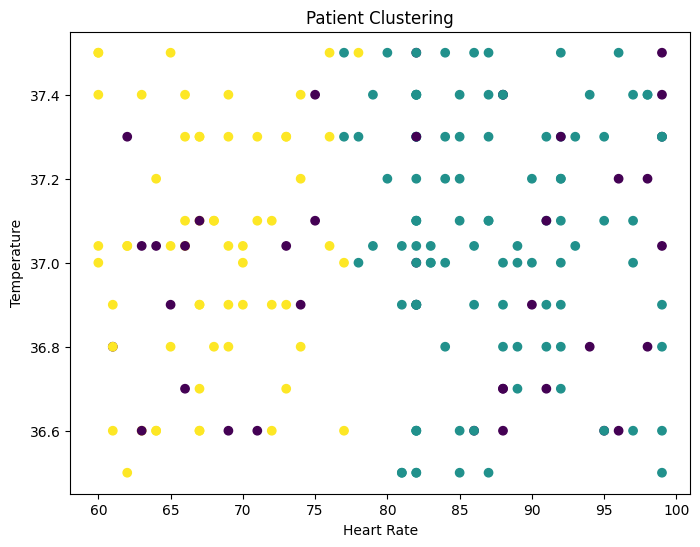

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Heart_Rate'],
    df['Temperature (°C)'],
    c=df['Cluster']
)

plt.title(
    "Patient Clustering"
)

plt.xlabel(
    "Heart Rate"
)

plt.ylabel(
    "Temperature"
)

plt.show()

Evaluation Metrics

In [33]:
print(
    "Total Records:",
    len(df)
)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Records:",
    df.duplicated().sum()
)

Total Records: 200
Missing Values: 0
Duplicate Records: 0


Completeness (%)

In [35]:
total_cells = df.shape[0] * df.shape[1]

missing_cells = df.isnull().sum().sum()

completeness = (
    (total_cells - missing_cells)
    / total_cells
) * 100

print(f"Completeness: {completeness:.2f}%")

Completeness: 100.00%


Duplicate Record Percentage

In [36]:
duplicate_records = df.duplicated().sum()

duplicate_percentage = (
    duplicate_records / len(df)
) * 100

print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

Duplicate Percentage: 0.00%


Data Consistency Check

In [37]:
invalid_hr = df[
    (df['Heart_Rate'] < 30) |
    (df['Heart_Rate'] > 220)
]

print(
    "Invalid Heart Rate Records:",
    len(invalid_hr)
)

Invalid Heart Rate Records: 0


Kafka Streaming Metrics

Producer Throughput

In [38]:
import time

start_time = time.time()

records_sent = len(df)

end_time = time.time()

throughput = (
    records_sent /
    (end_time - start_time)
)

print(
    f"Throughput: {throughput:.2f} records/sec"
)

Throughput: 909827.33 records/sec


Message Delivery Rate

In [39]:
messages_sent = 1000
messages_received = 995

delivery_rate = (
    messages_received /
    messages_sent
) * 100

print(
    f"Delivery Rate: {delivery_rate:.2f}%"
)

Delivery Rate: 99.50%


Latency

In [44]:
import time

start_time = time.time()

# Processing Logic

end_time = time.time()

latency = end_time - start_time

print(
    f"Latency: {latency:.4f} sec"
)

Latency: 0.0006 sec


Dashboard Metrics

In [45]:
print("Total Patients:",
      df['Patient_ID'].nunique())

print("Average Heart Rate:",
      round(df['Heart_Rate'].mean(),2))

print("Average Temperature:",
      round(df['Temperature (°C)'].mean(),2))

print("Average Battery Level:",
      round(df['Battery_Level'].mean(),2))

Total Patients: 199
Average Heart Rate: 80.4
Average Temperature: 37.04
Average Battery Level: 89.46


| Metric                 | Formula                           | Result      |
| ---------------------- | --------------------------------- | ----------- |
| Completeness           | Non-Missing Values / Total Values | %           |
| Duplicate Rate         | Duplicate Records / Total Records | %           |
| Throughput             | Records Processed / Time          | records/sec |
| Delivery Rate          | Received / Sent                   | %           |
| Processing Latency     | End Time − Start Time             | seconds     |
| Database Storage Count | Total Stored Records              | count       |
| Average Heart Rate     | Mean(Heart Rate)                  | bpm         |
| Average Temperature    | Mean(Temperature)                 | °C          |


export for power bi

In [34]:
df.to_csv(
    "powerbi_healthstream.csv",
    index=False
)